python -m venv venv_stat_app
python -m ipykernel install --user --name=venv_stat_app --display-name "Python (stat_app)"

In [7]:
# !pip install --upgrade pip

# !pip install datasets evaluate transformers accelerate
# !pip install torch
# !pip install transformers[torch]
# !pip install scikit-learn
# !pip install matplotlib
# !pip install tqdm
# !pip install xgboost

# JIGSAW


## LOADING/PREPROCESSING

In [ ]:
import os
import pandas as pd
import numpy as np

# =====================================================================
# 1. CONFIGURATION GLOBALE ET ARBORESCENCE DES DOSSIERS
# =====================================================================
DOSSIER_MERE = "INLP_Experiments"
DOSSIER_LIAR = f"{DOSSIER_MERE}/LIAR_data"

# Décommentez simplement la ligne que vous souhaitez étudier !
# target_cols, suffix, nom_categorie = ['male', 'female', 'transgender', 'other_gender'], "gender", "Gender"
# target_cols, suffix, nom_categorie = ['christian', 'jewish', 'muslim', 'hindu', 'buddhist', 'atheist', 'other_religion'], "religion", "Religion"
# target_cols, suffix, nom_categorie = ['heterosexual', 'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation'], "orientation", "Sexual Orientation"
target_cols, suffix, nom_categorie = ['physical_disability', 'intellectual_or_learning_disability', 'psychiatric_or_mental_illness', 'other_disability'], "disability", "Disability"
# target_cols, suffix, nom_categorie = ['black', 'white', 'asian', 'latino', 'other_race_or_ethnicity'], "race", "Race"

# Dossier spécifique à l'attribut en cours
DOSSIER_ATTRIBUT = f"{DOSSIER_MERE}/{suffix}"

# Création des dossiers (exist_ok=True empêche les erreurs si le dossier existe déjà)
os.makedirs(DOSSIER_LIAR, exist_ok=True)
os.makedirs(DOSSIER_ATTRIBUT, exist_ok=True)

print(f"Architecture prête :")
print(f" 📂 {DOSSIER_MERE}/")
print(f" ┣━ 📂 LIAR_data/      <- Vecteurs Fake News")
print(f" ┗━ 📂 {suffix}/          <- Matrices, graphiques et vecteurs pour {nom_categorie}")

Architecture prête :
 📂 INLP_Experiments/
 ┣━ 📂 LIAR_data/      <- Vecteurs Fake News
 ┗━ 📂 disability/          <- Matrices, graphiques et vecteurs pour Disability


In [9]:
# 2. Charger Jigsaw (Seulement les colonnes nécessaires)
cols_to_keep = ['comment_text'] + target_cols
df_jigsaw = pd.read_csv('/home/onyxia/work/Stat_App/Data/JIGSAW/all_data.csv', usecols=cols_to_keep)

# Nettoyer les valeurs nulles
df_jigsaw = df_jigsaw.dropna(subset=target_cols)

# 3. Créer les masques dynamiquement
masks = {}
for col in target_cols:
    mask = (df_jigsaw[col] >= 0.5) # La classe principale doit être >= 0.5
    for other_col in target_cols:
        if other_col != col:
            mask = mask & (df_jigsaw[other_col] < 0.5) # Toutes les autres strictement < 0.5
    masks[col] = mask

combined_mask = np.logical_or.reduce(list(masks.values()))
df_filtered = df_jigsaw[combined_mask].copy()

# 4. Assigner l'ID de la classe automatiquement (0, 1, 2...)
col_to_id = {col: i for i, col in enumerate(target_cols)}
conditions = [masks[col][combined_mask] for col in target_cols]
choices = [col_to_id[col] for col in target_cols]

df_filtered['z'] = np.select(conditions, choices, default=-1)

print(f"\nNombre total de textes conservés : {len(df_filtered)}")
print("Répartition :")
for col, z_id in col_to_id.items():
    print(f" - {col} (Classe {z_id}) : {(df_filtered['z'] == z_id).sum()} textes")

texts_jigsaw = df_filtered['comment_text'].tolist()
z_jigsaw = df_filtered['z'].values


Nombre total de textes conservés : 67840
Répartition :
 - male (Classe 0) : 28193 textes
 - female (Classe 1) : 37779 textes
 - transgender (Classe 2) : 1866 textes
 - other_gender (Classe 3) : 2 textes


## CLS

In [10]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm # Pour avoir une jolie barre de progression

# 1. Configuration du modèle et du matériel (GPU si possible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

# On charge la version de base de BERT (sans tête de classification, juste le corps)
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# On met le modèle en mode "évaluation" (désactive certaines fonctions d'entraînement comme le Dropout)
model.eval()

# 2. Fonction pour extraire les embeddings par lots (batches)
def get_bert_cls_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extraction BERT"):
        batch_texts = texts[i : i + batch_size]
        
        inputs = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=128, 
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())
        
    return np.vstack(all_embeddings)

# 3. Exécution sur vos textes Jigsaw (récupérés à l'étape précédente)
print("Début de l'extraction des vecteurs...")
X_jigsaw = get_bert_cls_embeddings(texts_jigsaw, batch_size=32)

print(f"Forme finale de la matrice X : {X_jigsaw.shape}")
# Devrait afficher (N, 768) où N est le nombre de textes et 768 la taille d'un vecteur BERT

np.save(f"{DOSSIER_ATTRIBUT}/jigsaw_bert_cls_{suffix}.npy", X_jigsaw)
np.save(f"{DOSSIER_ATTRIBUT}/jigsaw_labels_z_{suffix}.npy", z_jigsaw)

print(f"Sauvegarde terminée : 'jigsaw_bert_cls_{suffix}.npy' et 'jigsaw_labels_z_{suffix}.npy'")

Utilisation de l'appareil : cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Début de l'extraction des vecteurs...


Extraction BERT:   0%|          | 0/2120 [00:00<?, ?it/s]

Forme finale de la matrice X : (67840, 768)
Sauvegarde terminée : 'jigsaw_bert_cls_gender.npy' et 'jigsaw_labels_z_gender.npy'


# LIAR

## LOADING

In [11]:
from datasets import load_dataset
import csv

col_names = [
    "id", "label_text", "statement", "subject", "speaker", 
    "job_title", "state_info", "party_affiliation", 
    "barely_true_counts", "false_counts", "half_true_counts", 
    "mostly_true_counts", "pants_on_fire_counts", "context"
]

raw_datasets = load_dataset(
    "csv", 
    data_files={
        "train": "/home/onyxia/work/Stat_App/Data/LIAR/train.tsv", 
        "validation": "/home/onyxia/work/Stat_App/Data/LIAR/valid.tsv", 
        "test": "/home/onyxia/work/Stat_App/Data/LIAR/test.tsv"
    }, 
    delimiter="\t", 
    column_names=col_names,
    quoting=csv.QUOTE_NONE
)

label_mapping = {
    'pants-fire': 0, 
    'false': 1, 
    'barely-true': 2, 
    'half-true': 3, 
    'mostly-true': 4, 
    'true': 5
}

def map_labels(example):
    return {'label': label_mapping[example['label_text']]}

raw_datasets = raw_datasets.map(map_labels)

print(raw_datasets)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/10269 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1283 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 10269
    })
    validation: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 1284
    })
    test: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 1283
    })
})


## CLS

In [12]:
import numpy as np

# 1. Extraire les listes de textes et de labels de l'objet Hugging Face (LIAR)
print("Préparation des listes de textes LIAR...")
texts_liar_train = raw_datasets["train"]["statement"]
y_liar_train = raw_datasets["train"]["label"]

texts_liar_test = raw_datasets["test"]["statement"]
y_liar_test = raw_datasets["test"]["label"]

# 2. Convertir les textes en vecteurs BERT (Cela prendra quelques minutes)
print("\nExtraction des embeddings pour LIAR (Train)...")
X_liar_train = get_bert_cls_embeddings(texts_liar_train, batch_size=32)

print("\nExtraction des embeddings pour LIAR (Test)...")
X_liar_test = get_bert_cls_embeddings(texts_liar_test, batch_size=32)

# Vérification des dimensions
print(f"\nForme de X_train (LIAR) : {X_liar_train.shape}")
print(f"Forme de X_test (LIAR)  : {X_liar_test.shape}")

# 3. Sauvegarder les vecteurs LIAR dans leur dossier dédié
np.save(f"{DOSSIER_LIAR}/liar_train_bert_cls.npy", X_liar_train)
np.save(f"{DOSSIER_LIAR}/liar_train_labels.npy", y_liar_train)
np.save(f"{DOSSIER_LIAR}/liar_test_bert_cls.npy", X_liar_test)
np.save(f"{DOSSIER_LIAR}/liar_test_labels.npy", y_liar_test)

print(f"\nSauvegarde terminée dans le dossier {DOSSIER_LIAR}/")

print("\nSauvegarde terminée ! Les données LIAR sont vectorisées.")

Préparation des listes de textes LIAR...

Extraction des embeddings pour LIAR (Train)...


Extraction BERT:   0%|          | 0/321 [00:00<?, ?it/s]


Extraction des embeddings pour LIAR (Test)...


Extraction BERT:   0%|          | 0/41 [00:00<?, ?it/s]


Forme de X_train (LIAR) : (10269, 768)
Forme de X_test (LIAR)  : (1283, 768)

Sauvegarde terminée dans le dossier INLP_Experiments/LIAR_data/

Sauvegarde terminée ! Les données LIAR sont vectorisées.


# INLP

In [20]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import debias2
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 1. Charger les données Jigsaw (Dynamique)
X_jigsaw = np.load(f"{DOSSIER_ATTRIBUT}/jigsaw_bert_cls_{suffix}.npy")
z_jigsaw = np.load(f"{DOSSIER_ATTRIBUT}/jigsaw_labels_z_{suffix}.npy")

# 2. Charger les données LIAR (Fake News)
X_train_liar = np.load(f"{DOSSIER_LIAR}/liar_train_bert_cls.npy")
y_train_liar = np.load(f"{DOSSIER_LIAR}/liar_train_labels.npy")
X_test_liar = np.load(f"{DOSSIER_LIAR}/liar_test_bert_cls.npy")
y_test_liar = np.load(f"{DOSSIER_LIAR}/liar_test_labels.npy")

X_train_jigsaw, X_dev_jigsaw, z_train_jigsaw, z_dev_jigsaw = train_test_split(
    X_jigsaw, z_jigsaw, test_size=0.2, random_state=42, stratify=z_jigsaw 
)

# 3. Paramétrage dynamique de l'Adversaire et du point d'arrêt
num_classes = len(np.unique(z_jigsaw))
hasard = 1.0 / num_classes
min_acc_dynamic = hasard + 0.02 # Le hasard + 2% de marge

clf = LogisticRegression
clf_params = {'fit_intercept': True, 'class_weight': 'balanced', 'solver': 'lbfgs', 'max_iter': 100}

# 4. APPEL DE LA FONCTION INLP (En intégrant les données LIAR)
P_matrix, row_space_projections, Ws, P_intermediates, acc_jigsaw_list, acc_liar_list = debias2.get_debiasing_projection(
    classifier_class=clf,
    cls_params=clf_params,
    num_classifiers=25,
    input_dim=768,
    min_accuracy=min_acc_dynamic,
    X_train=X_train_jigsaw, Y_train=z_train_jigsaw,
    X_dev=X_dev_jigsaw, Y_dev=z_dev_jigsaw,
    X_train_main=X_train_liar, Y_train_main=y_train_liar,
    X_dev_main=X_test_liar, Y_dev_main=y_test_liar
)

# 5. SAUVEGARDE COMPLÈTE (Dynamique)
np.save(f"{DOSSIER_ATTRIBUT}/projection_matrix_{suffix}.npy", P_matrix)
np.save(f"{DOSSIER_ATTRIBUT}/row_space_projections_{suffix}.npy", np.array(row_space_projections, dtype=object))
np.save(f"{DOSSIER_ATTRIBUT}/Ws_{suffix}.npy", np.array(Ws, dtype=object))
np.save(f"{DOSSIER_ATTRIBUT}/P_intermediates_{suffix}.npy", np.array(P_intermediates, dtype=object))
np.save(f"{DOSSIER_ATTRIBUT}/acc_jigsaw_list_{suffix}.npy", np.array(acc_jigsaw_list))
np.save(f"{DOSSIER_ATTRIBUT}/acc_liar_list_{suffix}.npy", np.array(acc_liar_list))

print("\nAlgorithme INLP terminé et données sauvegardées avec succès !")

INLP Iterations:   0%|          | 0/25 [00:00<?, ?it/s]


Arrêt anticipé : L'accuracy 0.2577 est passée sous le seuil 0.27

Algorithme INLP terminé et données sauvegardées avec succès !


Chargement des historiques d'accuracy...

INLP Iteration  | Disability Accuracy  | Fake News Accuracy  
0               | 0.9619               | 0.2479              
1               | 0.7477               | 0.2502              
2               | 0.5526               | 0.2455              
3               | 0.5408               | 0.2440              
4               | 0.4637               | 0.2385              
5               | 0.3793               | 0.2447              
6               | 0.3675               | 0.2408              
7               | 0.3485               | 0.2518              
8               | 0.3085               | 0.2447              
9               | 0.3494               | 0.2486              
10              | 0.3203               | 0.2541              
11              | 0.2577               | 0.2416              



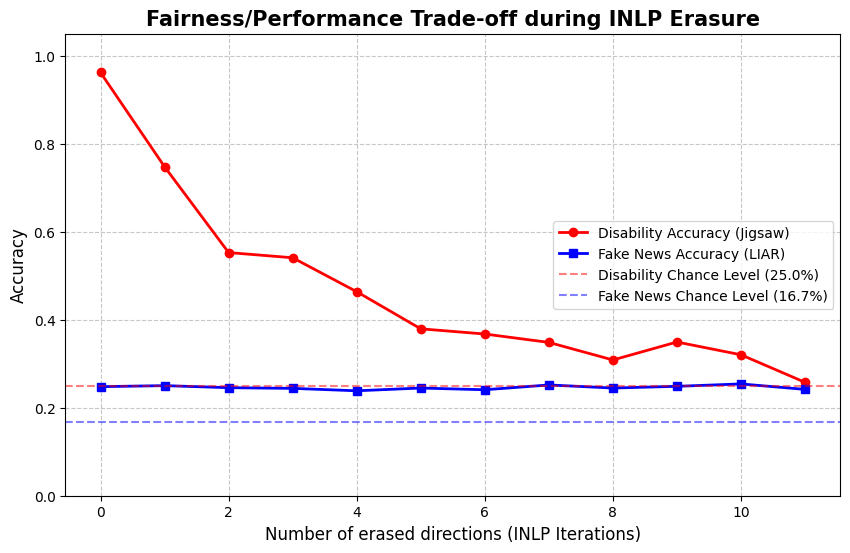

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. CHARGEMENT DES RÉSULTATS SAUVEGARDÉS
# =====================================================================
print("Chargement des historiques d'accuracy...")
acc_jigsaw_list = np.load(f"{DOSSIER_ATTRIBUT}/acc_jigsaw_list_{suffix}.npy")
acc_liar_list = np.load(f"{DOSSIER_ATTRIBUT}/acc_liar_list_{suffix}.npy")

# On recharge z_jigsaw juste pour connaître le nombre de classes (Ligne rouge)
z_jigsaw = np.load(f"{DOSSIER_ATTRIBUT}/jigsaw_labels_z_{suffix}.npy")
num_classes_jigsaw = len(np.unique(z_jigsaw))
hasard_jigsaw = 1.0 / num_classes_jigsaw

# NOUVEAU : On fait pareil pour LIAR (Ligne bleue)
y_liar = np.load(f"{DOSSIER_LIAR}/liar_train_labels.npy")
num_classes_liar = len(np.unique(y_liar))
hasard_liar = 1.0 / num_classes_liar

# =====================================================================
# 1.5. AFFICHAGE DES VALEURS DANS UN TABLEAU TEXTUEL
# =====================================================================
# Dans la cellule 19, section 1.5
print("\n" + "="*65)
print(f"{'INLP Iteration':<15} | {f'{nom_categorie} Accuracy':<20} | {'Fake News Accuracy':<20}")
print("="*65)
for i in range(len(acc_jigsaw_list)):
    print(f"{i:<15} | {acc_jigsaw_list[i]:<20.4f} | {acc_liar_list[i]:<20.4f}")
print("="*65 + "\n")

# =====================================================================
# 2. TRACÉ DU COMPROMIS ÉQUITÉ / PERFORMANCE DYNAMIQUE (EN ANGLAIS)
# =====================================================================
plt.figure(figsize=(10, 6))

iterations = range(len(acc_jigsaw_list))

# Traduction des labels des courbes
plt.plot(iterations, acc_jigsaw_list, marker='o', color='red', linewidth=2, label=f'{nom_categorie} Accuracy (Jigsaw)')
plt.plot(iterations, acc_liar_list, marker='s', color='blue', linewidth=2, label='Fake News Accuracy (LIAR)')

# Traduction des lignes de hasard
plt.axhline(y=hasard_jigsaw, color='red', linestyle='--', alpha=0.5, label=f'{nom_categorie} Chance Level ({hasard_jigsaw*100:.1f}%)')
plt.axhline(y=hasard_liar, color='blue', linestyle='--', alpha=0.5, label=f'Fake News Chance Level ({hasard_liar*100:.1f}%)')

# Traduction du titre et des axes
plt.title("Fairness/Performance Trade-off during INLP Erasure", fontsize=15, fontweight='bold')
plt.xlabel("Number of erased directions (INLP Iterations)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.05)

plt.legend(fontsize=10, loc='center right', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig(f"{DOSSIER_ATTRIBUT}/INLP_tradeoff_curve_{suffix}.png", dpi=300, bbox_inches='tight')
plt.show()

--- STEP 1: BEFORE INLP ---
Calcul de la LDA pour 'BERT Space (LDA) - Before INLP (Disability)'...


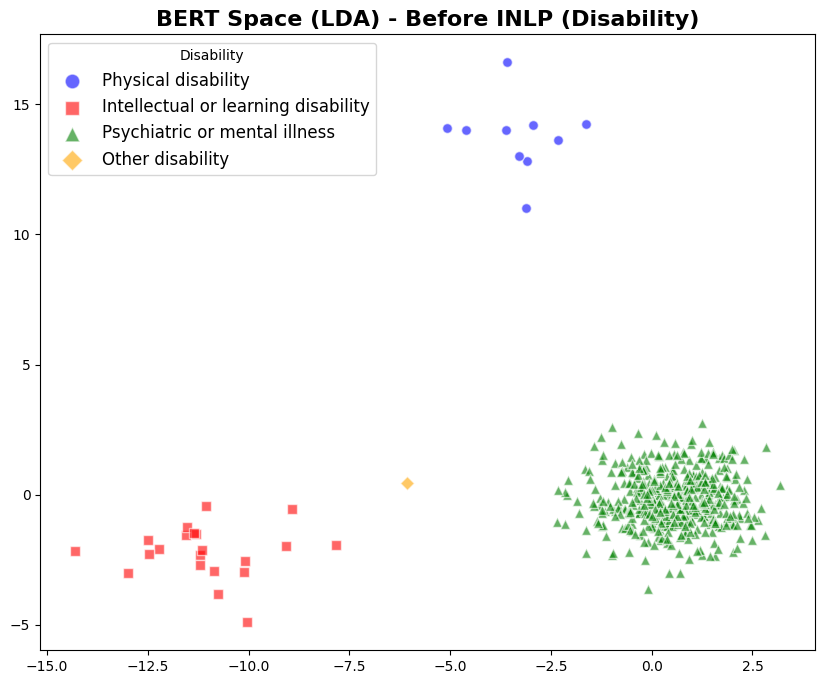


--- STEP 2: AFTER INLP ---
Calcul de la LDA pour 'BERT Space (LDA) - After INLP (Disability)'...


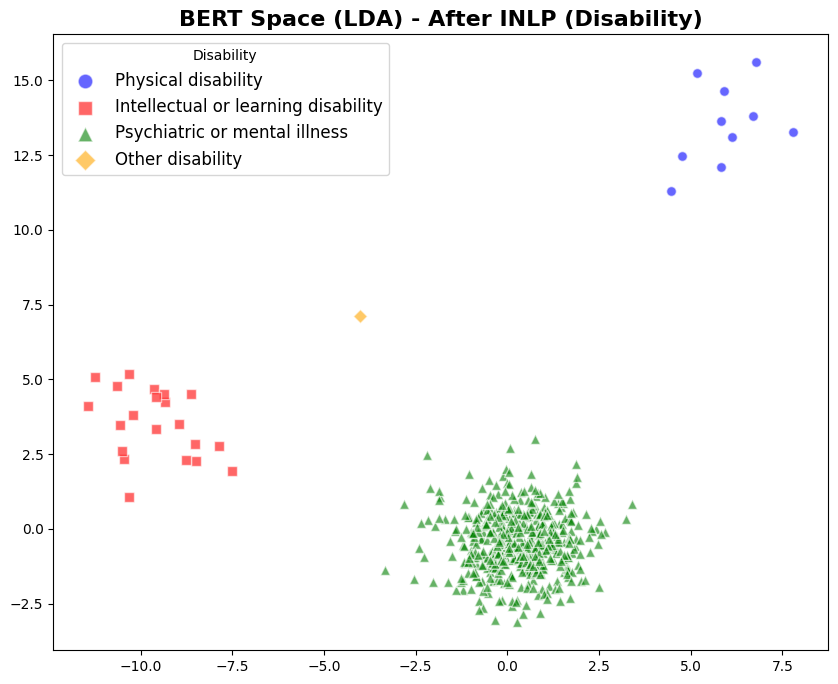

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CRÉATION DYNAMIQUE DU MAPPING ---
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

category_mapping = {}
for i, col in enumerate(target_cols):
    clean_name = col.replace('_', ' ').capitalize()
    category_mapping[i] = (clean_name, colors[i % len(colors)], markers[i % len(markers)])

# --- 2. FONCTION DE TRACÉ ---
def plot_lda_by_category(vecs, labels, title, mapping, legend_name="Catégorie"):
    print(f"Calcul de la LDA pour '{title}'...")
    
    lda = LDA(n_components=2)
    vecs_2d = lda.fit_transform(vecs, labels)
    
    plt.figure(figsize=(10, 8))
    unique_labels = sorted(list(set(labels.tolist())))
    
    for label in unique_labels:
        if label in mapping:
            name, color, marker = mapping[label]
            idx = (labels == label)
            
            plt.scatter(vecs_2d[idx, 0], vecs_2d[idx, 1], 
                        c=color, label=name, alpha=0.6, marker=marker, edgecolors='w', s=50)
            
    plt.legend(title=legend_name, fontsize=12, loc="best", markerscale=1.5)
    plt.title(title, fontsize=16, fontweight='bold')
    
    # MODIFICATION 1 : On ajoute le chemin vers le bon dossier !
    filename = f"{DOSSIER_ATTRIBUT}/{title.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')          
    plt.show()

# --- 3. PRÉPARATION DE L'ÉCHANTILLON ---
n_per_class = 500
indices_equilibres = []
num_classes = len(target_cols) 

for label in range(num_classes):
    idx_class = np.where(z_dev_jigsaw == label)[0]
    if len(idx_class) > 0:
        choix = np.random.choice(idx_class, min(n_per_class, len(idx_class)), replace=False)
        indices_equilibres.extend(choix)

X_sample = X_dev_jigsaw[indices_equilibres]
z_sample = z_dev_jigsaw[indices_equilibres]

print("--- STEP 1: BEFORE INLP ---")
plot_lda_by_category(
    X_sample, z_sample, 
    title=f"BERT Space (LDA) - Before INLP ({nom_categorie})",  # <--- TRADUIT
    mapping=category_mapping, 
    legend_name=nom_categorie
)

X_sample_debiased = P_matrix.dot(X_sample.T).T

print("\n--- STEP 2: AFTER INLP ---")
plot_lda_by_category(
    X_sample_debiased, z_sample, 
    title=f"BERT Space (LDA) - After INLP ({nom_categorie})",   # <--- TRADUIT
    mapping=category_mapping, 
    legend_name=nom_categorie
)

In [23]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

print("--- FINAL EVALUATION WITH A NON-LINEAR MODEL (MLP) ---")

# 1. Apply the final INLP projection on the LIAR dataset
X_train_liar_debiased = X_train_liar.dot(P_matrix)
X_test_liar_debiased = X_test_liar.dot(P_matrix)

# 2. Configure the Neural Network (2 hidden layers)
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(256, 128), 
    activation='relu',             
    solver='adam',                 
    max_iter=300, 
    early_stopping=True,           
    random_state=42
)

# 3. Training on DEBIASED vectors
mlp_clf.fit(X_train_liar_debiased, y_train_liar)

# 4. Evaluation
y_pred_mlp = mlp_clf.predict(X_test_liar_debiased)
acc_mlp = accuracy_score(y_test_liar, y_pred_mlp)

print(f"\nFinal Accuracy on LIAR (Non-linear MLP): {acc_mlp:.4f}")
print("\nDetailed classification report:")
print(classification_report(y_test_liar, y_pred_mlp))

--- FINAL EVALUATION WITH A NON-LINEAR MODEL (MLP) ---

Final Accuracy on LIAR (Non-linear MLP): 0.2486

Detailed classification report:
              precision    recall  f1-score   support

           0       0.27      0.16      0.20        92
           1       0.30      0.30      0.30       250
           2       0.25      0.15      0.19       214
           3       0.22      0.39      0.28       267
           4       0.24      0.30      0.27       249
           5       0.28      0.08      0.12       211

    accuracy                           0.25      1283
   macro avg       0.26      0.23      0.23      1283
weighted avg       0.26      0.25      0.24      1283



In [24]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

print("--- FINAL EVALUATION WITH XGBOOST ---")

# 1. Configure XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,      
    max_depth=6,           
    learning_rate=0.1,     
    n_jobs=-1,             
    random_state=42
)

# 2. Training on DEBIASED vectors
# Note: XGBoost expects labels from 0 to 5. 
xgb_clf.fit(X_train_liar_debiased, y_train_liar)

# 3. Evaluation
y_pred_xgb = xgb_clf.predict(X_test_liar_debiased)
acc_xgb = accuracy_score(y_test_liar, y_pred_xgb)

print(f"\nFinal Accuracy on LIAR (XGBoost): {acc_xgb:.4f}")
print("\nDetailed classification report:")
print(classification_report(y_test_liar, y_pred_xgb))

--- FINAL EVALUATION WITH XGBOOST ---

Final Accuracy on LIAR (XGBoost): 0.2463

Detailed classification report:
              precision    recall  f1-score   support

           0       0.47      0.10      0.16        92
           1       0.26      0.32      0.28       250
           2       0.24      0.21      0.23       214
           3       0.23      0.28      0.25       267
           4       0.24      0.29      0.26       249
           5       0.23      0.17      0.20       211

    accuracy                           0.25      1283
   macro avg       0.28      0.23      0.23      1283
weighted avg       0.26      0.25      0.24      1283



In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

print("--- FINAL EVALUATION WITH NON-LINEAR SVM (RBF Kernel) ---")

# 1. Configure the SVM with RBF kernel
svm_rbf_clf = SVC(
    kernel='rbf', 
    C=1.0,                   
    class_weight='balanced', 
    random_state=42
)

# 2. Training on DEBIASED vectors
svm_rbf_clf.fit(X_train_liar_debiased, y_train_liar)

# 3. Evaluation
y_pred_svm = svm_rbf_clf.predict(X_test_liar_debiased)
acc_svm = accuracy_score(y_test_liar, y_pred_svm)

print(f"\nFinal Accuracy on LIAR (RBF SVM): {acc_svm:.4f}")
print("\nDetailed classification report:")
print(classification_report(y_test_liar, y_pred_svm))

--- FINAL EVALUATION WITH NON-LINEAR SVM (RBF Kernel) ---

Final Accuracy on LIAR (RBF SVM): 0.2627

Detailed classification report:
              precision    recall  f1-score   support

           0       0.17      0.46      0.25        92
           1       0.33      0.20      0.25       250
           2       0.26      0.31      0.28       214
           3       0.24      0.15      0.18       267
           4       0.26      0.23      0.24       249
           5       0.34      0.39      0.37       211

    accuracy                           0.26      1283
   macro avg       0.27      0.29      0.26      1283
weighted avg       0.28      0.26      0.26      1283

